<a href="https://colab.research.google.com/github/padmarajanandhu-code/ICT-EXAM/blob/main/exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import joblib

In [ ]:
uploaded = files.upload()

Saving airbnb (1).xlsx.xlsx to airbnb (1).xlsx.xlsx


In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

df.head()

Saving airbnb (1).xlsx.xlsx to airbnb (1).xlsx (3).xlsx


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

In [ ]:
df.shape


(30475, 13)

In [ ]:
df.describe()

,Host Id,Host Since,Review Scores Rating (bin),Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
count,3.047500e+04,30475,22155.000000,30341.000000,30390.000000,30475.0,30475.000000,30475.000000,22155.000000
mean,1.273040e+07,2013-06-29 17:56:15.317473024,90.738659,10584.830691,1.530141,1.0,12.019852,163.598950,91.993230
min,5.000000e+02,2008-06-26 00:00:00,20.000000,1003.000000,0.000000,1.0,0.000000,10.000000,20.000000
25%,2.700193e+06,2012-06-21 00:00:00,85.000000,10017.000000,1.000000,1.0,0.000000,80.000000,89.000000
50%,8.551260e+06,2013-09-01 00:00:00,90.000000,10065.000000,1.000000,1.0,3.000000,125.000000,94.000000
75%,2.119605e+07,2014-09-12 00:00:00,100.000000,11216.000000,2.000000,1.0,13.000000,195.000000,100.000000
max,4.303307e+07,2015-08-31 00:00:00,100.000000,99135.000000,16.000000,1.0,257.000000,10000.000000,100.000000
std,1.190164e+07,NaN,9.059519,921.324686,1.015395,0.0,21.981496,197.792306,8.850373


In [ ]:
df.isnull().sum()

,0
Host Id,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


In [ ]:
df.columns

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')

In [ ]:
df["Host Since"] = pd.to_datetime(df["Host Since"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

In [ ]:
df["Host_Experience_Years"] = (
    pd.Timestamp.today() - df["Host Since"]
).dt.days / 365

In [ ]:
df[["Host Since", "Host_Experience_Years"]].head()

,Host Since,Host_Experience_Years
0,2008-06-26,18.019178
1,2008-06-26,18.019178
2,2008-07-25,17.939726
3,2008-08-12,17.890411
4,2008-08-15,17.882192


In [ ]:
#A new feature Host_Experience_Years has been created .
#It measures for how long the customer has been active .
#Hosts with more experience are likely to have better pricing and receive more positive reviews.
#This feature allows the model to capture the effect of host experience on listing prices.

In [ ]:
df.isnull().sum()

,0
Host Id,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


In [ ]:

missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100


missing_df = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

missing_df

,Missing Values,Missing Percentage
Host Id,0,0.00
Host Since,0,0.00
Name,0,0.00
Neighbourhood,0,0.00
Property Type,3,0.01
Review Scores Rating (bin),8320,27.30
Room Type,0,0.00
Zipcode,134,0.44
Beds,85,0.28
Number of Records,0,0.00


In [ ]:
df["Review Scores Rating"].describe()

,Review Scores Rating
count,22155.000000
mean,91.993230
std,8.850373
min,20.000000
25%,89.000000
50%,94.000000
75%,100.000000
max,100.000000


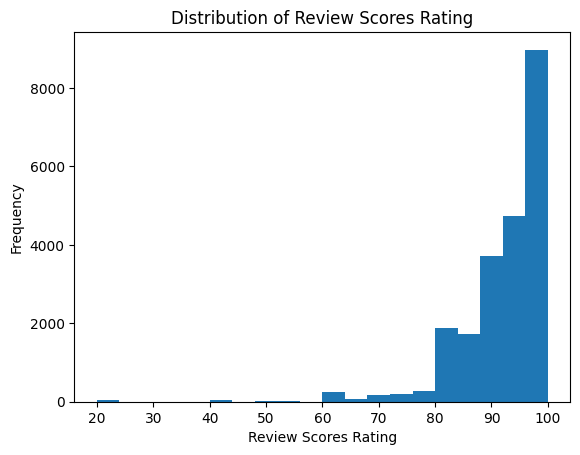

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Review Scores Rating"].dropna(), bins=20)
plt.xlabel("Review Scores Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Review Scores Rating")
plt.show()

In [ ]:
print("Mean:", df["Review Scores Rating"].mean())
print("Median:", df["Review Scores Rating"].median())

Mean: 91.99322951929587
Median: 94.0


In [ ]:
median_rating = df["Review Scores Rating"].median()

print("Median:", median_rating)

Median: 94.0


In [ ]:

df["Review Scores Rating"] = df["Review Scores Rating"].fillna(
    df["Review Scores Rating"].median()
)

In [ ]:
df["Review Scores Rating (bin)"] = df["Review Scores Rating (bin)"].fillna(
    df["Review Scores Rating (bin)"].median()
)

In [ ]:
df[["Review Scores Rating", "Review Scores Rating (bin)"]].isnull().sum()

,0
Review Scores Rating,0
Review Scores Rating (bin),0


In [ ]:
df.isnull().sum()

,0
Host Id,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),0
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


In [ ]:
#Missing values: 27.3%
#Distribution is left-skewed with a few low outliers.
#Median (94) is more robust than Mean (91.99).
#Hence, median imputation was used.

In [ ]:
df.columns.tolist()

['Host Id',
 'Host Since',
 'Name',
 'Neighbourhood ',
 'Property Type',
 'Review Scores Rating (bin)',
 'Room Type',
 'Zipcode',
 'Beds',
 'Number of Records',
 'Number Of Reviews',
 'Price',
 'Review Scores Rating',
 'Host_Experience_Years']

In [ ]:
df["Neighbourhood_RoomType"] = (
    df["Neighbourhood "].astype(str) + "_" +
    df["Room Type"].astype(str)
)

In [ ]:
# Dataset without interaction feature
df_without = df.copy()

# Dataset with interaction feature
df_with = df.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Neighbourhood ", "Room Type", "Property Type"]:
    df_without[col] = le.fit_transform(df_without[col].astype(str))
    df_with[col] = le.fit_transform(df_with[col].astype(str))

df_with["Neighbourhood_RoomType"] = le.fit_transform(
    df_with["Neighbourhood_RoomType"]
)

In [ ]:
df.head(3)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Host_Experience_Years,Neighbourhood_RoomType
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,90.0,Entire home/apt,10024.0,3.0,1,0,199,94.0,18.019178,Manhattan_Entire home/apt
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,18.019178,Manhattan_Private room
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0,17.939726,Brooklyn_Entire home/apt


In [ ]:
drop_cols = ["Host Since", "Name"]

df_without = df_without.drop(columns=drop_cols)
df_with = df_with.drop(columns=drop_cols)

In [ ]:
print(df.columns.tolist())

['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type', 'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Price', 'Review Scores Rating', 'Host_Experience_Years', 'Neighbourhood_RoomType']


In [ ]:
X1 = df_without.drop("Price", axis=1)
y1 = df_without["Price"]

X2 = df_with.drop("Price", axis=1)
y2 = df_with["Price"]

In [ ]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(random_state=42)
rf1.fit(X1_train, y1_train)

rf2 = RandomForestRegressor(random_state=42)
rf2.fit(X2_train, y2_train)

ValueError: could not convert string to float: 'Manhattan_Entire home/apt'

In [ ]:
print(X1.dtypes)
print(X2.dtypes)

Host Id                         int64
Neighbourhood                   int64
Property Type                   int64
Review Scores Rating (bin)    float64
Room Type                       int64
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Review Scores Rating          float64
Host_Experience_Years         float64
Neighbourhood_RoomType         object
dtype: object
Host Id                         int64
Neighbourhood                   int64
Property Type                   int64
Review Scores Rating (bin)    float64
Room Type                       int64
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Review Scores Rating          float64
Host_Experience_Years         float64
Neighbourhood_RoomType          int64
dtype: object


In [ ]:
df_without = df_without.drop(columns=["Neighbourhood_RoomType"])

In [ ]:
X1 = df_without.drop("Price", axis=1)
y1 = df_without["Price"]

In [ ]:
print(X1.select_dtypes(include="object").columns)

Index([], dtype='object')


In [ ]:
print(X1.columns)

Index(['Host Id', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Review Scores Rating',
       'Host_Experience_Years'],
      dtype='object')


In [ ]:
df_without = df_without.drop(columns=["Neighbourhood_RoomType"], errors="ignore")

X1 = df_without.drop("Price", axis=1)
y1 = df_without["Price"]

In [ ]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42
)

X2 = df_with.drop("Price", axis=1)
y2 = df_with["Price"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X1_train.select_dtypes(include="object").columns)
print(X2_train.select_dtypes(include="object").columns)

Index([], dtype='object')
Index([], dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(random_state=42)
rf1.fit(X1_train, y1_train)

rf2 = RandomForestRegressor(random_state=42)
rf2.fit(X2_train, y2_train)

RandomForestRegressor(random_state=42)

In [ ]:
pred1 = rf1.predict(X1_test)
pred2 = rf2.predict(X2_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse1 = np.sqrt(mean_squared_error(y1_test, pred1))
rmse2 = np.sqrt(mean_squared_error(y2_test, pred2))

print("RMSE without interaction feature:", rmse1)
print("RMSE with interaction feature:", rmse2)

RMSE without interaction feature: 164.1151566200462
RMSE with interaction feature: 164.82245611613462


In [ ]:
# RMSE without interaction feature: 164.1151566200462
# RMSE with interaction feature: 164.82245611613462
# The interaction feature did not improve the model's performance, as the RMSE increased slightly.
# The Random Forest model is capable of learning complex relationships between `Neighbourhood` and `Room Type`
# even without creating their interaction.

In [ ]:
# Best-performing dataset (without interaction feature)
X = df_without.drop("Price", axis=1)
y = df_without["Price"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(random_state=42)

final_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = final_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Final Model RMSE:", rmse)

Final Model RMSE: 164.1151566200462


In [ ]:
#An RMSE of 164.12 means the model's predicted Airbnb price differs from the actual price by about 164 units on average.
#Lower RMSE indicates better prediction accuracy.

In [ ]:
import joblib

joblib.dump(final_model, "airbnb_model.pkl")

['airbnb_model.pkl']

In [ ]:
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)

# Load the trained model
model = joblib.load("airbnb_model.pkl")

@app.route('/predict', methods=['POST'])
def predict():

    data = request.get_json()

    features = np.array([
        data['Host Id'],
        data['Neighbourhood'],
        data['Property Type'],
        data['Review Scores Rating (bin)'],
        data['Room Type'],
        data['Zipcode'],
        data['Beds'],
        data['Number of Records'],
        data['Number Of Reviews'],
        data['Review Scores Rating'],
        data['Host_Experience_Years']
    ]).reshape(1, -1)

    prediction = model.predict(features)

    return jsonify({
        "Predicted Price": float(prediction[0])
    })

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
